In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

sns.set_style('whitegrid')

# The Foul, the Whistle and the Doubt: building a statistical case from football data

*How to turn a pub argument into a statistical test.*

## Surprisingly Consistent: What Football Fouls Tell Us About Everything Else

Every football fan, and I am among them, has watched the same match twice: once on the pitch, once in their head on the way home. The referee was biased. The opposition dived. Your team's fouls were marginal challenges; theirs were cynical and deliberate. The scoreline was wrong.

This is not a complaint. This is data.

Across a full season, some teams are whistled for fouls at rates that differ significantly from others. Some receive a yellow card every seven fouls; others every eleven. Whether that gap reflects how teams play, how referees decide, or simply how crowds behave is exactly the kind of question statistics was built to answer.

We are going to look at fouls. Fouls committed, if you prefer to assign responsibility to the team. Fouls called by the referee, if you prefer to assign it to the official. The data is the same either way. Which framing you instinctively reach for probably says something about which team you support.

By the end of this article, you will have the tools to take that instinct seriously. Not to confirm it. To test it.


In [2]:
with open('./data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

print(f"Rows: {len(team_matches):,}")
print(f"Leagues: {sorted(team_matches['league'].unique())}")
print(f"Seasons: {sorted(team_matches['season'].unique())}")


Rows: 50,060
Leagues: ['Bundesliga', 'La_Liga', 'Ligue_1', 'Premier_League', 'Serie_A']
Seasons: ['1112', '1213', '1314', '1415', '1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']


## 1. Where Do We Start?

Before testing anything, we need to understand the data we are working with. This is not a formality. Every statistical test makes assumptions about the shape and behaviour of the data it receives. Running a test without checking those assumptions first is like cross-examining a witness without reading their statement. You might still reach the right conclusion, but you will not know why, and you will not notice when you are wrong.

We start with a single question: 

> how are fouls distributed across a match?

Not which team fouls more, not whether referees are consistent, not whether home teams behave differently from away teams. Just: if you picked a random match from our dataset, what would you expect to see? And how much would you expect that number to vary?

This is always the right first question. Everything else follows from it. Maybe non everything, but a lot.


### Choosing a starting point

We have data from five leagues and fourteen seasons. We could look at everything at once, but that would mix together leagues with very different styles of play, referees with different thresholds, and seasons separated by a decade of rule changes.

Instead we start with a single league and a single season. Once we understand the patterns in one controlled setting, we can ask whether they hold more broadly. This is standard analytical practice: understand one thing well before generalising.

We use the most recent complete season in our dataset, 2024/25, and we begin with Serie A.

In [3]:
serie_a_2425 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2425')
].copy()

print(f"Rows: {len(serie_a_2425)}")
print(f"Matches: {len(serie_a_2425) // 2}")
print(f"Teams: {serie_a_2425['team'].nunique()}")
print(f"Date range: {serie_a_2425['date'].min().date()} to {serie_a_2425['date'].max().date()}")


Rows: 760
Matches: 380
Teams: 20
Date range: 2024-08-17 to 2025-05-25


A complete season: 380 matches, 20 teams, running from August 2024 to May 2025. Each match appears twice in the dataframe, once for each team's perspective, giving 760 rows. This is exactly what we expect from a 20-team league and a useful first confirmation that the data is intact.

Now let us look at the fouls.

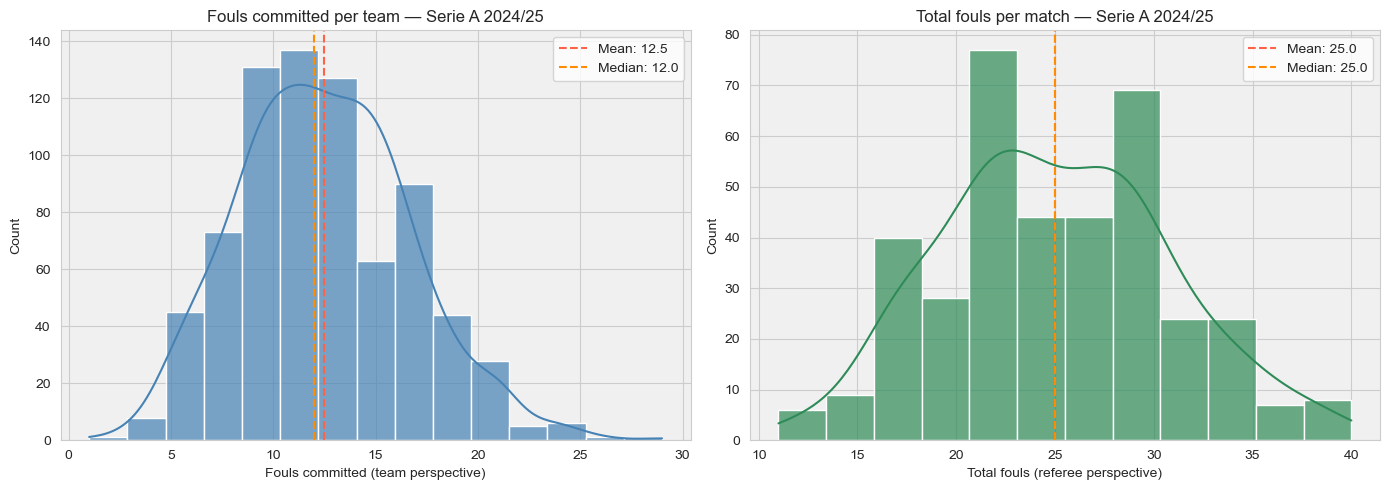

In [4]:
match_fouls = serie_a_2425[serie_a_2425['venue'] == 'home'].copy()
match_fouls['total_fouls'] = match_fouls['fouls_committed'] + match_fouls['fouls_received']

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (data, title, xlabel, color, bins) in zip(axes, [
        (serie_a_2425['fouls_committed'],
         'Fouls committed per team — Serie A 2024/25',
         'Fouls committed (team perspective)',
         'steelblue', 15),
        (match_fouls['total_fouls'],
         'Total fouls per match — Serie A 2024/25',
         'Total fouls (referee perspective)',
         'seagreen', 12),
    ]):
        ax.set_facecolor('#f0f0f0')
        sns.histplot(data, bins=bins, kde=True, color=color, alpha=0.7, ax=ax)
        ax.axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.5,
                   label=f"Mean: {data.mean():.1f}")
        ax.axvline(data.median(), color='darkorange', linestyle='--', linewidth=1.5,
                   label=f"Median: {data.median():.1f}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()

plt.tight_layout()


### What do we see?

Two distributions, two perspectives on the same matches, and already two different stories.

On the left, fouls ***committed per team***. The distribution is roughly bell-shaped and centred around 12.5 fouls per match, with mean and median almost identical. This near-symmetry is our first useful signal: when mean and median sit this close together, the distribution is not being pulled hard in either direction by extreme values. A team committing 5 fouls in a match is about as unusual as a team committing 20.

On the right, ***total fouls per match*** from the referee's perspective. The average is exactly double, as it should be: 25 fouls per match is simply two teams each committing around 12.5. But the shape is less clean. There is a peak around 20, a dip, and then a second bump around 28. This irregularity is worth noting. It might be noise, it might reflect two distinct refereeing styles in the league, or it might be a seasonal effect. We will not chase it here, but we will keep it in mind.

For now, the left plot is the one we need. A roughly symmetric distribution with mean and median close together is well-behaved enough to apply the tools we are about to introduce. Not perfectly normal, but close enough to start. We will verify that assumption formally in a moment.


In [5]:
print("Fouls committed per team — summary statistics")
print(serie_a_2425['fouls_committed'].describe().round(2))
print()
print("Total fouls per match — summary statistics")
print(match_fouls['total_fouls'].describe().round(2))


Fouls committed per team — summary statistics
count    760.00
mean      12.50
std        4.18
min        1.00
25%       10.00
50%       12.00
75%       15.00
max       29.00
Name: fouls_committed, dtype: float64

Total fouls per match — summary statistics
count    380.00
mean      25.00
std        5.79
min       11.00
25%       21.00
50%       25.00
75%       29.00
max       40.00
Name: total_fouls, dtype: float64


The numbers confirm what the plots suggested, and add a few details worth unpacking.

**Fouls committed per team:** the mean is 12.5 and the median is 12.0, close but not identical. The standard deviation of 4.2 tells us that roughly two thirds of observations fall between 8 and 17 fouls, which feels intuitively right for a professional football match. The minimum of 1 is unusual but possible: a team that barely challenges for the ball, or a match where the referee was unusually lenient. The maximum of 29 is at the other extreme, a very physical performance from someone.

**Total fouls per match:** mean and median are both exactly 25, and the standard deviation of 5.8 is slightly less than double the per-team value of 4.2. If the two teams' foul counts were completely independent, we would expect the match total to have a standard deviation of roughly 4.2 times the square root of 2, which is about 5.9. The fact that we observe 5.8 is reassuringly close to that theoretical value.

One thing to carry forward: the interquartile range for per-team fouls runs from 10 to 15, a spread of 5 fouls. Half of all team performances in Serie A 2024/25 sit within that narrow band. Football feels chaotic from the stands. The foul count, it turns out, is surprisingly predictable.

## The Model and the Reality

The distribution we just looked at has a familiar shape: roughly symmetric, centred around a single peak, tailing off on both sides. This is what statisticians call a normal distribution, or Gaussian. Before we use it to run any tests, it is worth asking what it actually means to say that data follows a normal distribution, and whether we should trust that claim here.

A model is an approximation of reality. When we say that fouls per match follow a normal distribution, we are not claiming that football is secretly governed by a mathematical equation. We are saying that the normal distribution is a reasonable description of what we observe, close enough to be useful without pretending to be exact.

The normal distribution has a convenient property: it is fully described by just two numbers, the mean and the standard deviation. If the model fits, those two numbers tell us almost everything: where the centre of the distribution is, how wide the spread is, and how likely any particular value is. The familiar 68-95-99.7 rule follows directly: roughly 68% of observations fall within one standard deviation of the mean, 95% within two, and 99.7% within three.

But how do we know if the model fits well enough to trust? We check it against the data.


In [6]:
from scipy.stats import norm

# fit the Gaussian model to the data: estimate mean and standard deviation
mu = match_fouls['total_fouls'].mean()
sigma = match_fouls['total_fouls'].std()

# ask the model: what fraction of matches should exceed 30 fouls?
# norm.cdf gives the probability of being BELOW a threshold
# so 1 - norm.cdf gives the probability of being ABOVE it
threshold = 30
p_model = 1 - norm.cdf(threshold, loc=mu, scale=sigma)

# ask the data: what fraction of matches actually exceeded 30 fouls?
p_actual = (match_fouls['total_fouls'] > threshold).mean()

print(f"Gaussian model: mean = {mu:.1f}, std = {sigma:.1f}")
print()
print(f"P(total fouls > {threshold}) according to the model:  {p_model:.3f} ({p_model*100:.1f}%)")
print(f"Fraction of matches with > {threshold} fouls in data: {p_actual:.3f} ({p_actual*100:.1f}%)")
print(f"Difference: {abs(p_model - p_actual)*100:.1f} percentage points")


Gaussian model: mean = 25.0, std = 5.8

P(total fouls > 30) according to the model:  0.194 (19.4%)
Fraction of matches with > 30 fouls in data: 0.166 (16.6%)
Difference: 2.8 percentage points


Let us walk through what the code is doing, because each step maps directly onto a conceptual choice.

`mu` and `sigma` are estimated from the data itself. We are not choosing these values arbitrarily: we are letting the data tell us where the centre of the distribution is and how wide the spread is. This is called *fitting the model*.

`norm.cdf(threshold, loc=mu, scale=sigma)` is the cumulative distribution function of the Gaussian evaluated at 30. In plain terms: given our model, what is the probability that a randomly picked match has 30 or fewer total fouls? The CDF always returns a value between 0 and 1. Subtracting from 1 gives us the probability of exceeding the threshold, which is what we want.

`(match_fouls['total_fouls'] > threshold).mean()` does something much simpler: it counts how many rows in the actual data have more than 30 fouls and divides by the total number of rows. No model, no assumptions. Just counting.

The comparison between the two numbers is the whole point. The model gives us a prediction. The data gives us the ground truth. How close they are tells us how much we can trust the model when we use it to make statements about matches we have not seen yet.

The model predicts that roughly 19% of matches should have more than 30 total fouls. The actual figure in the data is 16.6%. A gap of 2.8 percentage points.

That is larger than I would like, and it is worth being honest about why. Cast your mind back to the right-hand plot from the previous section: the total fouls distribution had an irregular shape, with a peak around 20, a dip, and a second bump around 28. A symmetric Gaussian centred at 25 does not capture that shape particularly well. It overestimates the probability of high-foul matches because it assumes the data spreads evenly in both directions from the mean, which it does not quite do here.

So should we abandon the Gaussian? Not necessarily. The question is not whether the model is perfect but whether it is good enough for what we need it to do. For a rough sense of what is likely and unlikely, a 2.8 percentage point error is acceptable. For a precise forecast of how many matches will exceed 30 fouls, it is not.

This is the tradeoff at the heart of statistical modelling. A more complex model could fit the data more precisely, but it would be ***harder to interpret***, ***slower to compute***, and more ***difficult to explain***. The normal distribution earns its place not because it is always exactly right, but because it is the simplest model that is often close enough, and because its two parameters, the mean and the standard deviation, have an immediate intuitive meaning that more complex alternatives do not.

For the team-level analysis that follows, we will be working with fouls committed per team rather than total fouls per match. That distribution, as we saw, is better behaved. We will check it formally in a moment. But it is worth carrying this example as a reminder: every time we use a model, we are making a choice about how much approximation we are willing to accept.

## 3. Outliers and Unlikely Events: a Necessary Distinction



Before we run any formal test, I want to draw a distinction that gets blurred surprisingly often, including by people who should know better.

When something unusual appears in the data, there are two very different ways to describe it. The first is to call it an **outlier**: a data point that sits far from the centre of the distribution by a geometric criterion. The second is to call it **statistically unlikely**: a result that would be surprising if the underlying process were random.

These sound like the same thing. They are not.

An outlier is defined by where a data point sits relative to the rest of the data. The standard definition uses the interquartile range: any point that falls more than 1.5 times the IQR below the first quartile or above the third quartile is flagged as an outlier. This is a rule of thumb about distance. It says nothing about probability.

Statistical likelihood, by contrast, is about the model. A p-value asks: if the data were generated by a random process with no systematic effect, how often would we see a result at least as extreme as this one? It is a statement about a hypothetical world, not about the data point itself.

A team can be an outlier without being statistically significant: it might sit just beyond the 1.5 IQR boundary but still be well within the range of what random variation can produce. Equally, a result can be statistically significant without any individual data point being an outlier: a small but consistent shift in the mean across hundreds of matches will show up in a hypothesis test long before it produces a visible outlier.

We will use both tools in this article. The important thing is to know which question each one is answering.


In [7]:
def get_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper

outliers, lower, upper = get_outliers(serie_a_2425['fouls_committed'])

print(f"IQR boundaries: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers found: {len(outliers)}")
print(f"As a fraction of all observations: {len(outliers)/len(serie_a_2425):.3f} ({len(outliers)/len(serie_a_2425)*100:.1f}%)")
print()
print(outliers.describe().round(2))

IQR boundaries: [2.5, 22.5]
Outliers found: 12
As a fraction of all observations: 0.016 (1.6%)

count    12.00
mean     22.50
std       6.97
min       1.00
25%      23.00
50%      24.00
75%      24.25
max      29.00
Name: fouls_committed, dtype: float64


Twelve data points fall outside the IQR boundaries, six on each side roughly speaking, representing 1.6% of all observations. The boundaries sit at 2.5 fouls on the lower end and 22.5 on the upper end.

A few things worth noting here.

The lower boundary of 2.5 means that any team committing fewer than 3 fouls in a match is flagged as an outlier. Looking at the minimum of 1 foul in the dataset, that is a genuinely unusual match: a team that barely made a challenge all game, whether through exceptional discipline, an extremely passive tactical approach, or a particularly lenient referee.

The upper outliers cluster tightly between 23 and 29 fouls. Their mean is 22.5, almost exactly at the boundary, which tells us these are not extreme cases far out in the tail but rather points sitting just beyond the geometric cutoff. Whether they represent genuinely anomalous performances or simply the natural right tail of the distribution is exactly the kind of question a hypothesis test, rather than the outlier criterion, is designed to answer.

This is the distinction in action. The IQR rule has flagged these 12 observations. It has not told us whether they are surprising. For that, we need the model.

There is a second reason to look at outliers that has nothing to do with statistics: data quality.

Before treating an extreme value as a signal, it is worth asking whether it is actually correct. A team committing 1 foul in a match is unusual. A team committing 0 fouls in a match is suspicious. When I first ran this check on an earlier version of the dataset, I found matches recorded with zero fouls for one or both teams. Some of them turned out to be genuine edge cases: matches where the referee was exceptionally lenient or where the data source had a known gap. Others were errors: matches that had been incorrectly scraped or recorded, where the real foul count was missing and had silently been filled with zero.

The outlier check did not tell me which was which. It just told me where to look. I had to go back to the source for each flagged match and verify manually. This is unglamorous work, but it is the kind of work that sits between having data and trusting data.

In the current dataset, after the cleaning steps described in the appendix, the minimum recorded foul count is 1. We have no zero-foul matches remaining. But the lesson holds: always check your outliers before you analyse them. An extreme value that turns out to be a data error will distort every test you run downstream, often in ways that are difficult to detect after the fact.



In [8]:
zero_fouls = team_matches[team_matches['fouls_committed'] == 0][
    ['league', 'season', 'date', 'team', 'opponent', 'fouls_committed', 'yellow_cards', 'venue']
].sort_values('date')

print(f"Matches with zero fouls recorded for one team: {len(zero_fouls)}")
print()
print(zero_fouls.to_string(index=False))


Matches with zero fouls recorded for one team: 4

        league season       date     team opponent  fouls_committed  yellow_cards venue
       La_Liga   1718 2018-04-22 Sociedad   Malaga              0.0           1.0  away
Premier_League   1819 2019-04-20   Wolves Brighton              0.0           0.0  home
Premier_League   1920 2019-11-30  Chelsea West Ham              0.0           0.0  home
       Ligue_1   2122 2022-05-21   Rennes    Lille              0.0           2.0  away


When I first ran this check across the full dataset, covering five leagues and fourteen seasons, I went looking for zero-foul matches. Not because I expected them to be errors, but because zero fouls in a professional football match is the kind of number that makes you pause.

I found four of them, spread across three different leagues. Three turned out to be genuine: verified against a second source, one team really had not been whistled for a single foul. The Malaga vs Real Sociedad case is my personal favourite: the visiting team committed zero fouls and still received a yellow card, presumably for time-wasting. A player who managed to irritate the referee without ever making a challenge. I like to think that takes a specific kind of talent.

The fourth match, Lille vs Rennes, was a data error. The source recorded zero fouls for one team; a second source reported a normal-looking number. Someone had entered the wrong value, or the scraper had picked up an empty field and interpreted it as zero.

I will be honest: verifying these required going back to match records and, in two cases, watching enough old highlights on YouTube to confirm what the referee had or had not whistled. This is not the glamorous part of data science. And also, the popcorn were too salty and not enough beer. Come to think of it, this is precisely what I was doing during my PhD. The only difference is that back then I called it research.

The lesson from this exercise is worth stating clearly. An outlier is a data point that sits far from the rest by a geometric criterion. It is not automatically an error, and it is not automatically a signal. It is a flag that says: look here before you proceed. What you find when you look determines everything else.


## 4. Normal, But How Normal?

We have established that a Gaussian model is a reasonable approximation for fouls data, and we have seen that it is not perfect. Now we need to be more precise about what "reasonable" means before we use it to run hypothesis tests.

The tests we are about to introduce, starting with the t-test, assume that the data is approximately normally distributed. If that assumption is badly violated, the test results become unreliable. Not wrong in an obvious way, just quietly untrustworthy, which is worse. Feeding an [abby-normal](https://www.youtube.com/watch?v=Z7L3PcrhnEg) distribution into a test that expects a well-behaved one is the kind of mistake that produces results that look perfectly reasonable right up until they don't.

We check normality in two ways: one visual, one formal. Neither is definitive on its own. Together they give an honest picture.

The visual check is a Q-Q plot, which compares the quantiles of our data against the quantiles of a theoretical normal distribution. If the data were perfectly normal, every point would sit exactly on the diagonal line. Deviations from the line tell us where and how the data departs from normality.

The formal check is the Shapiro-Wilk test, which returns a p-value for the null hypothesis that the data was drawn from a normal distribution. A low p-value means we can reject that hypothesis. A high p-value means we cannot, which is not quite the same as confirming normality, but is good enough for our purposes.

One important caveat before we run anything: with large samples, the Shapiro-Wilk test becomes extremely sensitive. It will flag even tiny, practically irrelevant departures from normality as statistically significant. So we read the two checks together, and we use judgement.

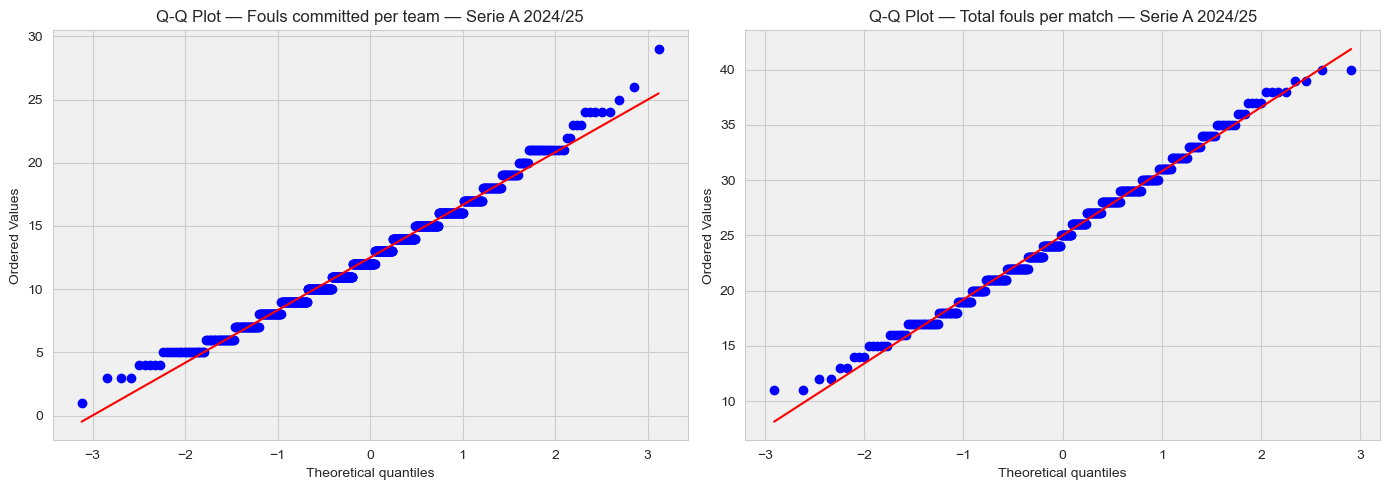

In [9]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

with sns.axes_style("whitegrid"):
    for ax, (data, label) in zip(axes, [
        (serie_a_2425['fouls_committed'], 'Fouls committed per team'),
        (match_fouls['total_fouls'], 'Total fouls per match'),
    ]):
        ax.set_facecolor('#f0f0f0')
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label} — Serie A 2024/25')

plt.tight_layout()


In [10]:
for label, data in [
    ('Fouls committed per team', serie_a_2425['fouls_committed']),
    ('Total fouls per match',    match_fouls['total_fouls']),
]:
    stat, p = stats.shapiro(data)
    print(f"{label}")
    print(f"  W = {stat:.4f},  p = {p:.4f}  —  {'normal (p > 0.05)' if p > 0.05 else 'not normal (p < 0.05)'}")
    print()


Fouls committed per team
  W = 0.9878,  p = 0.0000  —  not normal (p < 0.05)

Total fouls per match
  W = 0.9916,  p = 0.0306  —  not normal (p < 0.05)



Both distributions are flagged as not normal by the Shapiro-Wilk test. Before we panic, let us read these results carefully.

The W statistics are 0.988 and 0.992. The maximum possible value is 1.0, which would indicate perfect normality. These values are very close to 1. The test is not telling us the data is badly non-normal. It is telling us the data is not *perfectly* normal, and with 760 and 380 observations respectively, it has enough [statistical power](https://en.wikipedia.org/wiki/Power_(statistics)) to be certain about that.

This is the large-sample sensitivity problem we warned about. With enough data, Shapiro-Wilk will reject normality for almost any real-world dataset, because real-world data is never exactly Gaussian. The question is not whether the test rejects, but by how much and where.

The Q-Q plots give the more useful answer. For fouls committed per team, the points follow the diagonal line closely through the entire middle of the distribution. The only meaningful departures are in the lower left tail, where a cluster of points sits below the line. These correspond to the low-foul matches we identified as outliers earlier: the ones worth checking but not necessarily errors. The upper tail is clean.

For total fouls per match the fit is even better, with only slight deviations at both extremes.

Our conclusion: both distributions are approximately normal in the region that matters for hypothesis testing, which is the bulk of the data. The tails depart from normality, as real data almost always does. This is not a reason to abandon the Gaussian model. It is a reason to stay alert and to verify our conclusions with tests that make fewer assumptions, which we will do throughout this article.


## Is There a Home Advantage in Fouling?

Now that we understand the shape of the data and have a model we can reasonably trust, we can ask our first real question.

> Football folklore, the kind that gets settled in pubs and reopened the following weekend, is full of claims about home advantage: home teams win more, score more, and are awarded more favourable decisions. But do they foul differently? Specifically, do away teams commit more fouls than home teams, and if so, is that difference large enough to be something other than random noise?

This is exactly the kind of argument that sounds *settled before anyone has looked at the data*. Away teams are under more pressure, defending deeper, chasing the game more often. Of course they foul more. Everyone at the bar agrees.

I thought so too. Let us check.

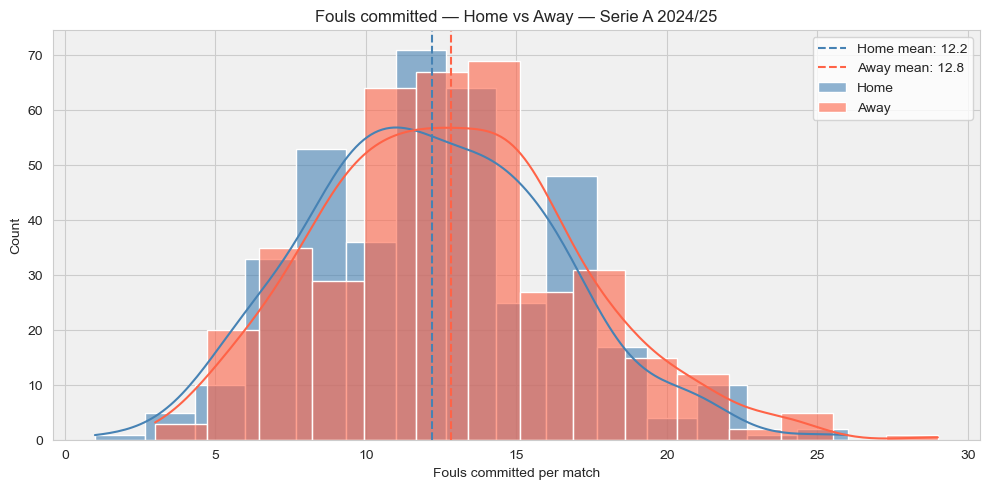

In [11]:
home_fouls = serie_a_2425[serie_a_2425['venue'] == 'home']['fouls_committed']
away_fouls = serie_a_2425[serie_a_2425['venue'] == 'away']['fouls_committed']

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')

    sns.histplot(home_fouls, bins=15, kde=True, color='steelblue', alpha=0.6,
                 label='Home', ax=ax)
    sns.histplot(away_fouls, bins=15, kde=True, color='tomato', alpha=0.6,
                 label='Away', ax=ax)

    ax.axvline(home_fouls.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Home mean: {home_fouls.mean():.1f}')
    ax.axvline(away_fouls.mean(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'Away mean: {away_fouls.mean():.1f}')

    ax.set_xlabel('Fouls committed per match')
    ax.set_ylabel('Count')
    ax.set_title('Fouls committed — Home vs Away — Serie A 2024/25')
    ax.legend()
    plt.tight_layout()


In [12]:
print("Serie A 2024/25 — Fouls committed per match")
print()
print(serie_a_2425.groupby('venue')['fouls_committed'].describe().round(2))


Serie A 2024/25 — Fouls committed per match

       count   mean   std  min   25%   50%   75%   max
venue                                                 
away   380.0  12.82  4.24  3.0  10.0  13.0  15.0  29.0
home   380.0  12.18  4.09  1.0   9.0  12.0  15.0  26.0


The plot and the numbers tell the same story. Away teams average 12.8 fouls per match, home teams 12.2. A gap of 0.6 fouls per match, in the direction the pub consensus predicted.

But look more carefully before declaring victory for conventional wisdom. The medians are 13 and 12 respectively, close but not identical. The standard deviations are almost the same: 4.24 for away, 4.09 for home. The interquartile ranges overlap almost completely: both groups sit between 9 and 15 fouls for the middle 50% of observations. The distributions in the plot are barely distinguishable.

The 0.6 foul gap is real in the sense that it exists in the data. Whether it is real in the sense of reflecting a ***genuine systematic difference***, rather than the kind of fluctuation you would expect simply from random variation, is a different question entirely. And that is precisely the question that a hypothesis test is designed to answer.

This is the moment where the pub argument hands over to the statistics. Everyone agrees the away mean is higher. The question is whether that is signal or noise. It's time to take the beer out (just for a moment), put on our lab coat, and find out.

## Introducing Hypothesis Testing

A hypothesis test is a formal way of asking: could this difference have happened by chance?

We start by assuming the most boring possible explanation is true. In our case: home and away teams foul at exactly the same rate, and the 0.6 foul gap we observed is just random variation. This assumption is called the **null hypothesis**. It is not what we believe. It is the position we are trying to argue against.

We then ask: if the null hypothesis were true, how likely is it that we would observe a difference at least as large as 0.6 fouls per match? This probability is the **p-value**.

If the p-value is very small, it means our data would be highly unlikely in a world where the null hypothesis is true. That gives us reason to doubt the null hypothesis and lean towards the alternative: that the difference is real.

If the p-value is large, it means our data is perfectly consistent with random variation. The null hypothesis survives, not because we have proven it true, but because we have not found enough evidence to reject it.

The threshold we use to decide between "small enough" and "not small enough" is called **alpha**, typically set at 0.05. This is a convention, not a law of nature. It means we are willing to incorrectly reject a true null hypothesis 5% of the time. That accepted error rate is a choice, and like all choices in statistics, it has consequences.

One thing alpha is not: a measure of how important or large the effect is. A p-value below 0.05 tells you the result is unlikely under the null hypothesis. It tells you nothing about whether the effect is worth caring about. We will come back to this distinction.


### Football and Pregnancy Tests

$\alpha$ needs a closer look, because it is one of those concepts that sounds simple and turns out to have real consequences when you get it wrong.

When we set $\alpha$ to 0.05, we are not saying "results with a p-value below 0.05 are true and results above it are false." We are saying something more specific and more uncomfortable: if we repeated this experiment one hundred times in a world where the null hypothesis is actually true, we would expect to incorrectly reject it up to five times. Those five cases are false positives. We have decided, in advance, that we can live with that error rate.

This is not a flaw in the method. It is an honest acknowledgement of what statistical testing can and cannot do. The choice of alpha is a choice about how many false positives you are willing to accept, and it should be made before you look at the results, not after.

Why does this matter beyond football? Because the same framework governs every diagnostic test ever designed.

Think of a pregnancy test. No diagnostic test is 100% accurate: it is possible to get a positive result when you are not pregnant, and possible, though rarer, to get a negative result when you are. When a test is developed, its designers choose thresholds that determine the false positive rate and the false negative rate. $\alpha$ is one of the parameters that influences this balance. A stricter threshold reduces false positives but increases false negatives. A looser threshold does the opposite. The choice depends on what is at stake.

The mathematics underneath a test for home advantage in Serie A and a test for the presence of a virus in a blood sample are, structurally, identical. The hypotheses are different. The data is different. The stakes are very different. But the logic is the same: assume the null, quantify the surprise, decide whether the evidence is strong enough to act on.

This is why statistical literacy is not a niche skill for people who like spreadsheets. It is the language in which a large fraction of consequential decisions in medicine, public health, economics and science are made. Learning to read it, even imperfectly, gives you something increasingly rare: the ability to ask the right questions about the numbers being used to justify those decisions.

Football is just a good place to start. The referee decisions are lower stakes. The data is public. And at least one person in every pub already has a strong opinion about the result.

### Checking Assumptions Before Running the Test

Every statistical test comes with a set of assumptions. Running a test without checking them is like reading the verdict before hearing the evidence: you might still reach the right conclusion, but you have no way of knowing.

The t-test has two main assumptions:

**Normality**: the data in each group should be approximately normally distributed. We have already checked this for the overall distribution of fouls. Now we need to check it separately for the home and away groups.

**Equal variance**: the Student's t-test assumes that the two groups have similar spread. If the variances are very different, the test can give misleading results. We check this with Levene's test, which returns a p-value for the null hypothesis that the two groups have equal variance. A low p-value means the variances differ significantly and we should use a version of the t-test that does not require this assumption.

We check both before we run anything.


### A Brief and Entirely Justified Historical Detour

Before we run the t-test, I want to tell you where it comes from. Bear with me. This is relevant, I promise, and it involves gambling and beer.

If you think probability and statistics were born from the minds of brilliant mathematicians pondering the nature of the universe, you are partly right. A very small part. The calculus of probability begins with [Gerolamo Cardano](https://en.wikipedia.org/wiki/Gerolamo_Cardano), an astrologer and compulsive gambler, and two of the most extraordinary mathematical minds in history: [Pierre de Fermat](https://en.wikipedia.org/wiki/Pierre_de_Fermat) and [Blaise Pascal](https://en.wikipedia.org/wiki/Blaise_Pascal).

Cardano wrote the first book on games of chance, the *Liber de ludo aleae*, in which he attempted to explain gambling in terms of probability. He also included, with admirable candour, instructions for cheating. Whether his mathematical insights helped him at the table is answered by the fact that he spent most of his life drowning in debt. Brilliant, but not quite brilliant enough where it counted.

Fermat and Pascal are another matter. Two of the greatest mathematicians of the seventeenth century, and when they found time to correspond with each other, what were they discussing? Gambling. Specifically, how to correctly evaluate the fairness of a bet and whether a player could gain a systematic statistical advantage in games of chance. Pascal later used the same principles to construct a philosophical argument for the existence of God, which is either a natural extension of the same logic or a sign that he needed to get out more. As for whether their correspondence solved the gambling problem: the answer is provided by the life of the [Chevalier de Méré](https://en.wikipedia.org/wiki/Antoine_Gombaud), the nobleman who had originally consulted them seeking an edge. He kept losing.

Now, what about hypothesis testing? What about this t-test we are about to use to decide whether home and away teams foul at different rates? Where does that come from?

Beer. Guinness, to be precise.

The Student's t-test was developed by [William Sealy Gosset](https://en.wikipedia.org/wiki/William_Sealy_Gosset), a statistician and chemist employed by the Guinness brewery whose job was to monitor the quality of barley and hops. Working with small samples, he needed a rigorous way to compare means and determine whether differences were real or just noise. He invented one. When he published his findings, however, Guinness would not allow him to use his real name, concerned about revealing their methods to competitors. So he published under a pseudonym. He chose *Student*. And that is why, when you run a Student's t-test in any statistical software in the world, you are using a method invented to improve the consistency of Irish stout.

Gambling and beer. If you cannot find these topics engaging, I am not sure what else I can offer you.

End of historical detour. We are moving from beer to football, so at least the narrative continuity holds.

In [13]:
# check equal variance assumption before choosing which t-test to use
lev_stat, lev_p = stats.levene(home_fouls, away_fouls)

print("Levene's test for equal variance")
print(f"  F = {lev_stat:.4f},  p = {lev_p:.4f}")
print(f"  Equal variance? {'Yes (p > 0.05)' if lev_p > 0.05 else 'No (p < 0.05)'}")
print()

# normality check on each group separately
for label, data in [('Home', home_fouls), ('Away', away_fouls)]:
    stat, p = stats.shapiro(data)
    print(f"Shapiro-Wilk — {label}: W = {stat:.4f},  p = {p:.4f}  —  {'normal' if p > 0.05 else 'not normal'}")


Levene's test for equal variance
  F = 0.3883,  p = 0.5334
  Equal variance? Yes (p > 0.05)

Shapiro-Wilk — Home: W = 0.9896,  p = 0.0087  —  not normal
Shapiro-Wilk — Away: W = 0.9848,  p = 0.0005  —  not normal


The assumption checks give us a clear picture.

**Equal variance:** Levene's test returns p = 0.53, well above $\alpha$ = 0.05. The two groups spread similarly around their means, consistent with the near-identical standard deviations we saw earlier (4.09 vs 4.24).

**Normality:** both groups are flagged as not normal, but with W statistics of 0.990 and 0.985 this is the large-sample sensitivity issue we already discussed in section 4. The departure from normality is real but negligible for our purposes.

Equal variance is satisfied. Normality is approximately satisfied. We run both Student's and Welch's t-test: since the variances are equal, they should agree. If they do, we can trust the conclusion.

In [14]:
# Student's t-test (assumes equal variance)
t_stat_s, p_s = stats.ttest_ind(home_fouls, away_fouls, equal_var=True)

# Welch's t-test (does not assume equal variance)
t_stat_w, p_w = stats.ttest_ind(home_fouls, away_fouls, equal_var=False)

print(f"Observed difference (away - home): {away_fouls.mean() - home_fouls.mean():.2f} fouls per match")
print()
print(f"Student's t-test:  t = {t_stat_s:.4f},  p = {p_s:.4f}")
print(f"Welch's t-test:    t = {t_stat_w:.4f},  p = {p_w:.4f}")
print()
print(f"Significant at alpha = 0.05? {'Yes' if p_w < 0.05 else 'No'}")


Observed difference (away - home): 0.63 fouls per match

Student's t-test:  t = -2.0963,  p = 0.0364
Welch's t-test:    t = -2.0963,  p = 0.0364

Significant at alpha = 0.05? Yes


Both tests return identical results, as we expected given that Levene's test confirmed equal variance. When the assumptions are met, Student's and Welch's t-test agree. That consistency is itself reassuring.

The result is statistically significant: p = 0.036, below our $\alpha$ of 0.05. Away teams commit significantly more fouls than home teams in Serie A 2024/25. The pub consensus, it turns out, had a point.

But before anyone orders a celebratory round, let us read this result carefully.

The difference is 0.63 fouls per match. Over a 38-match season that amounts to roughly 24 extra fouls committed away from home. Spread across 38 matches, that is less than one additional foul per game. The effect is real in the statistical sense: it is unlikely to be noise. Whether it is meaningful in any practical sense is a different question entirely.

This is the distinction between ***statistical significance*** and ***practical significance***. A p-value below $\alpha$ tells us the result is unlikely under the null hypothesis. It says nothing about whether the effect is large enough to matter. With 380 observations per group, even a very small true difference will eventually produce a significant p-value. The test is sensitive enough to detect it. Sensitive enough to care about it is a judgement call that no p-value can make for you.

We will quantify the size of the effect properly in a moment. For now, note that $p = 0.036$ is significant but not emphatic. It sits just below the threshold. Had we chosen $\alpha$ = 0.01 instead of 0.05, this result would not have cleared the bar. That is not a reason to dismiss it, but it is a reason to hold it lightly.

In [15]:
# Cohen's d: a standardised measure of effect size
pooled_std = np.sqrt((home_fouls.std()**2 + away_fouls.std()**2) / 2)
cohens_d = (away_fouls.mean() - home_fouls.mean()) / pooled_std

print(f"Cohen's d: {cohens_d:.4f}")
print()
print("Conventional benchmarks:")
print("  Small effect:  d ~ 0.2")
print("  Medium effect: d ~ 0.5")
print("  Large effect:  d ~ 0.8")

Cohen's d: 0.1521

Conventional benchmarks:
  Small effect:  d ~ 0.2
  Medium effect: d ~ 0.5
  Large effect:  d ~ 0.8


Cohen's d of 0.15 is below the conventional threshold for a small effect. To put it concretely: if you picked a random home performance and a random away performance, the away team would have more fouls roughly 54% of the time. That figure comes directly from $d$: for a normally distributed effect, the probability that a random observation from one group exceeds a random observation from the other is approximately equal to the area under the normal curve up to $d$ divided by the square root of 2, which for $d = 0.15$ gives us about 0.54. Barely better than a coin flip.

This is what "statistically significant but practically small" looks like in numbers. The test detected a real signal. The signal is just not very loud.

A useful way to think about it: the 0.63 foul difference is real, in the sense that it almost certainly exists in the population and is not a fluke of this particular season. But it is small relative to the natural variation in the data, a standard deviation of roughly 4 fouls per match. The difference between the most and least aggressive teams in the league will turn out to be many times larger than the home-away gap. That is the comparison that actually matters if you are trying to understand which teams foul differently, and it is where we are heading next.

For now, the home-away question has an honest answer: yes, away teams foul slightly more, the difference is statistically real, and it is too small to build any strong conclusions on. The pub argument was directionally correct and quantitatively unimpressive. Welcome to statistics.

Before we zoom into individual teams, I want to try something. We have just built a hypothesis testing toolkit: check the assumptions, run the test, measure the effect size, interpret honestly. It took some work to put together. It would be a shame not to take it for a spin on a different question before we move on.

Here is one that has been sitting in the back of my mind since we first plotted the total fouls per match distribution: 

> Do referees in England call fewer fouls than in Italy?

English football has a reputation for physicality. Crunching tackles, aerial battles, relentless pressing. The kind of football where the referee puts the whistle away and lets the game flow. Italian football, by contrast, has a reputation for tactical fouling, shirt-pulling, and a creative relationship with the laws of the game. These are stereotypes, of course. But stereotypes have to come from somewhere.

We have the data. We have the tools. Let us find out if the stereotypes survive contact with a t-test.

In [16]:
prem_2425 = team_matches[
    (team_matches['league'] == 'Premier_League') &
    (team_matches['season'] == '2425')
].copy()

prem_match_fouls = prem_2425[prem_2425['venue'] == 'home'].copy()
prem_match_fouls['total_fouls'] = prem_match_fouls['fouls_committed'] + prem_match_fouls['fouls_received']

print("Serie A 2024/25")
print(f"  Matches: {len(match_fouls)}")
print(f"  Total fouls per match: {match_fouls['total_fouls'].mean():.1f} +/- {match_fouls['total_fouls'].std():.1f}")
print()
print("Premier League 2024/25")
print(f"  Matches: {len(prem_match_fouls)}")
print(f"  Total fouls per match: {prem_match_fouls['total_fouls'].mean():.1f} +/- {prem_match_fouls['total_fouls'].std():.1f}")


Serie A 2024/25
  Matches: 380
  Total fouls per match: 25.0 +/- 5.8

Premier League 2024/25
  Matches: 380
  Total fouls per match: 22.1 +/- 5.3


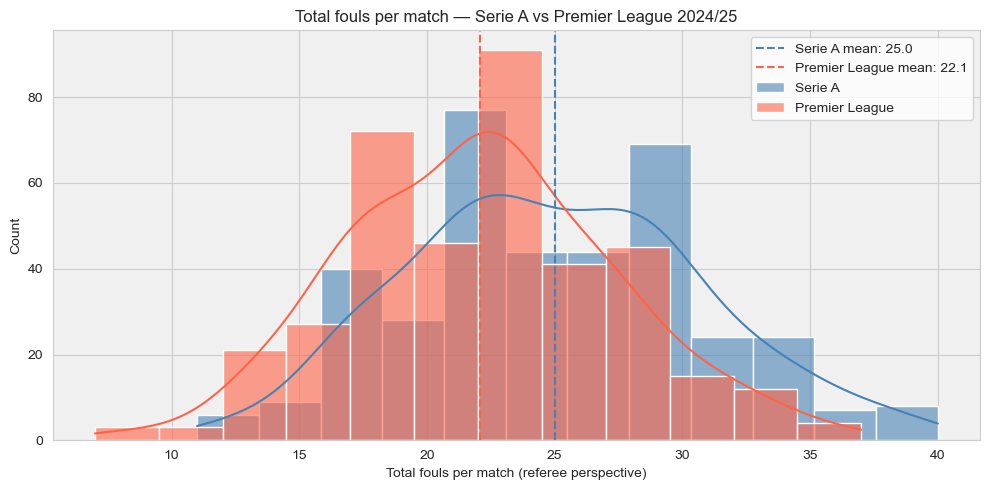

In [17]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')

    sns.histplot(match_fouls['total_fouls'], bins=12, kde=True,
                 color='steelblue', alpha=0.6, label='Serie A', ax=ax)
    sns.histplot(prem_match_fouls['total_fouls'], bins=12, kde=True,
                 color='tomato', alpha=0.6, label='Premier League', ax=ax)

    ax.axvline(match_fouls['total_fouls'].mean(), color='steelblue',
               linestyle='--', linewidth=1.5,
               label=f"Serie A mean: {match_fouls['total_fouls'].mean():.1f}")
    ax.axvline(prem_match_fouls['total_fouls'].mean(), color='tomato',
               linestyle='--', linewidth=1.5,
               label=f"Premier League mean: {prem_match_fouls['total_fouls'].mean():.1f}")

    ax.set_xlabel('Total fouls per match (referee perspective)')
    ax.set_ylabel('Count')
    ax.set_title('Total fouls per match — Serie A vs Premier League 2024/25')
    ax.legend()
    plt.tight_layout()


In [18]:
lev_stat, lev_p = stats.levene(match_fouls['total_fouls'], prem_match_fouls['total_fouls'])

t_stat, p_val = stats.ttest_ind(match_fouls['total_fouls'], 
                                 prem_match_fouls['total_fouls'], 
                                 equal_var=False)

pooled_std = np.sqrt((match_fouls['total_fouls'].std()**2 + 
                      prem_match_fouls['total_fouls'].std()**2) / 2)
cohens_d = (match_fouls['total_fouls'].mean() - 
            prem_match_fouls['total_fouls'].mean()) / pooled_std

print(f"Observed difference (Serie A - Premier League): {match_fouls['total_fouls'].mean() - prem_match_fouls['total_fouls'].mean():.2f} fouls per match")
print()
print(f"Levene's test:   F = {lev_stat:.4f},  p = {lev_p:.4f}")
print(f"Welch's t-test:  t = {t_stat:.4f},  p = {p_val:.4f}")
print(f"Cohen's d:       {cohens_d:.4f}")
print()
print(f"Significant at alpha = 0.05? {'Yes' if p_val < 0.05 else 'No'}")


Observed difference (Serie A - Premier League): 2.94 fouls per match

Levene's test:   F = 5.5035,  p = 0.0192
Welch's t-test:  t = 7.3090,  p = 0.0000
Cohen's d:       0.5303

Significant at alpha = 0.05? Yes


Now that is a different story entirely.

A difference of 2.94 fouls per match between Serie A and the Premier League! Welch's t-test returns $p-value$ essentially zero, and Cohen's $d$ of 0.53 sits squarely in the *medium-to-large range*. Compare this to the home-away result: $p-value = 0.036$, $d = 0.15$. Same toolkit, completely different answer.

Notice that Levene's test flagged unequal variance this time (p = 0.019), which is why we used Welch's rather than Student's. The Serie A distribution is wider than the Premier League one, something the plot already hinted at: the blue distribution stretches further into the high-foul tail. This is exactly the kind of assumption check that matters: had we blindly applied Student's t-test, we would have used the wrong tool without knowing it.

The stereotype, it turns out, is not just a stereotype. Italian referees call significantly more fouls than English ones, by nearly three per match. Over a 38-match season that is over 100 extra fouls whistled per team in Serie A compared to the Premier League. Whether that reflects a difference in how the game is played, how referees are instructed, or how the laws are interpreted is a question the data alone cannot answer. But the gap is real, it is large, and it survives every check we have thrown at it.

This is what a meaningful effect looks like. Keep it in mind as we turn back to individual teams within Serie A, where the differences will be smaller and the tests will have to work harder.

## Do Some Teams Foul More Than Others?

We have seen that away teams foul slightly more than home teams, and that Italian referees call significantly more fouls than English ones. Both comparisons treated teams as interchangeable: a foul is a foul, whoever commits it.

Now we ask the question that every fan in every pub is actually interested in: are some teams genuinely different from the rest? Is there a team that systematically commits more fouls than the league average, or one that somehow glides through matches barely touching anyone?

For each team we run the same test: their fouls per match against everyone else in the league. One team versus the rest. The groups are unequal in size, roughly 38 matches against 722, so we use Welch's t-test throughout. We also compute Cohen's d for each team so we can distinguish teams that are statistically different from teams that are meaningfully different.


In [19]:
results = []

for team_name in serie_a_2425['team'].unique():
    team = serie_a_2425[serie_a_2425['team'] == team_name]['fouls_committed']
    rest = serie_a_2425[serie_a_2425['team'] != team_name]['fouls_committed']

    t_stat, p_val = stats.ttest_ind(team, rest, equal_var=False)

    observed_diff = team.mean() - rest.mean()
    pooled_std = np.sqrt((team.std()**2 + rest.std()**2) / 2)
    cohens_d = observed_diff / pooled_std

    results.append({
        'team': team_name,
        'mean': team.mean(),
        'std': team.std(),
        'n': len(team),
        'diff_from_rest': observed_diff,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'significant': p_val < 0.05
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('mean', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

results_df


,team,mean,std,n,diff_from_rest,p_value,cohens_d,significant
0,Verona,15.2368,5.1906,38,2.8795,0.0017,0.6172,True
1,Empoli,14.8947,4.6370,38,2.5194,0.0021,0.5745,True
2,Udinese,14.1053,3.3352,38,1.6884,0.0045,0.4449,True
3,Bologna,14.0789,3.3642,38,1.6607,0.0055,0.4362,True
4,Monza,13.4474,5.1449,38,0.9958,0.2476,0.2137,False
5,Venezia,13.2368,3.9211,38,0.7742,0.2439,0.1908,False
6,Cagliari,13.1579,4.2460,38,0.6911,0.3334,0.1641,False
7,Como,13.0789,4.2451,38,0.6080,0.3941,0.1444,False
8,Genoa,13.0526,3.4402,38,0.5803,0.3224,0.1509,False
9,Juventus,12.6579,3.5434,38,0.1648,0.7834,0.0423,False


The table is sorted by mean fouls committed per match, and the picture it paints is not subtle. Ten of the twenty teams cross the significance threshold of $\alpha = 0.05$, split almost evenly between those fouling more than the rest and those fouling less.

At the top, Verona and Empoli stand out with Cohen's d above 0.5: that is a medium effect by any standard measure. Udinese and Bologna follow closely. These are not teams that are marginally rougher than their peers. The gap is real and consistent enough to survive a statistical test.

At the other end, Roma and Parma have the largest negative effects. Roma is the mirror image of Verona: similar magnitude, opposite direction. Inter, Napoli, Milan and Lazio cluster just below that, all with effects between -0.38 and -0.43.

The ten teams in between are statistically unremarkable. Their p-values do not cross the threshold, which does not mean they foul at exactly the same rate as everyone else. It means there is not enough evidence in one season's data to say they are different. A distinction worth keeping.

One thing the table does not tell us is why. A high-fouling team might be tactically aggressive, might play in a defensive style that invites more contact, or might simply have a squad that picks up calls more readily. A low-fouling team might press more, control the ball more, or face a different kind of opponent on average.

The numbers are not a verdict. They are a starting point.

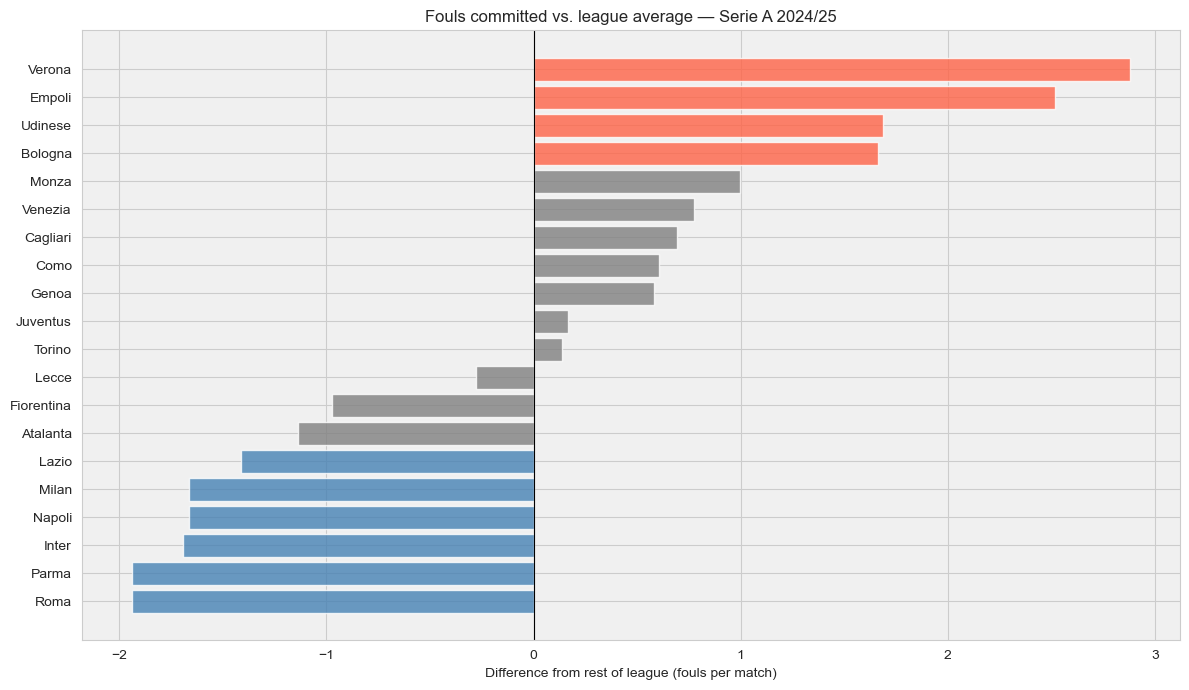

In [20]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_facecolor('#f0f0f0')

    plot_df = results_df.sort_values('diff_from_rest', ascending=False).copy()

    colors = [
        'tomato' if (row['significant'] and row['cohens_d'] > 0)
        else 'steelblue' if (row['significant'] and row['cohens_d'] < 0)
        else 'grey'
        for _, row in plot_df.iterrows()
    ]

    ax.barh(plot_df['team'], plot_df['diff_from_rest'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Difference from rest of league (fouls per match)')
    ax.set_title('Fouls committed vs. league average — Serie A 2024/25')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

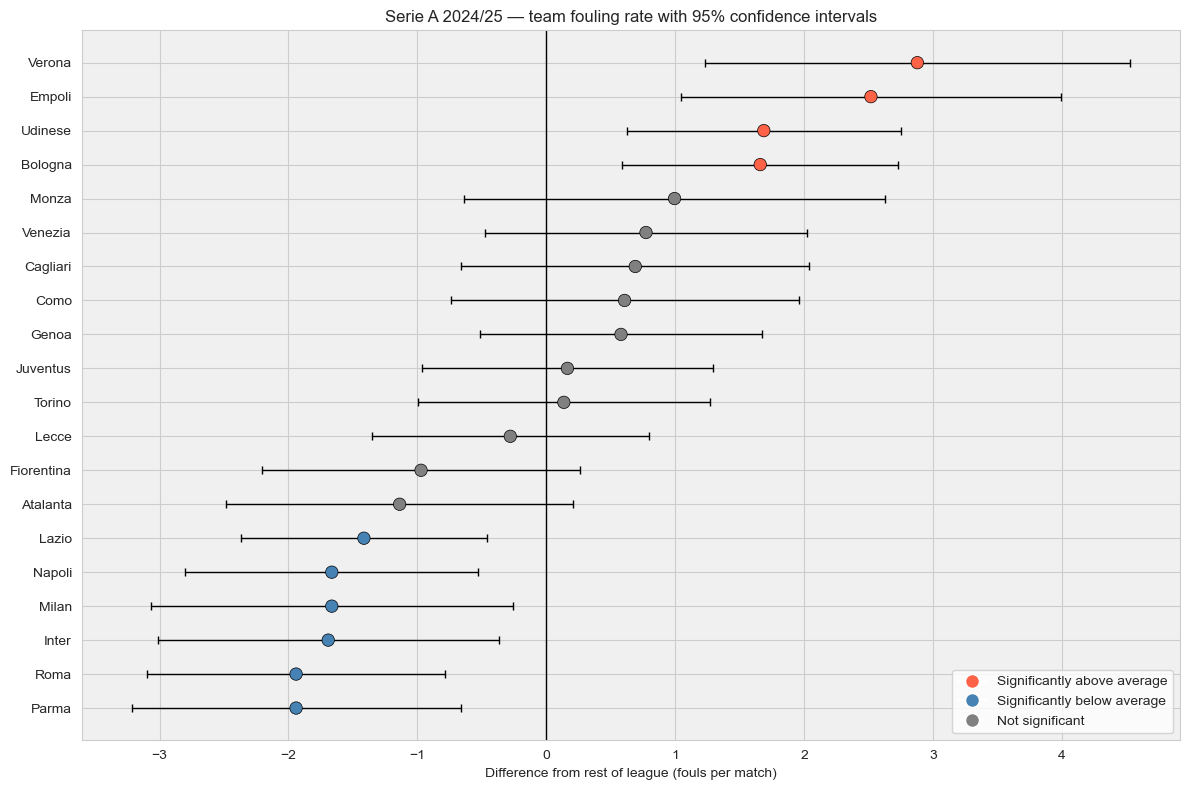

In [21]:
from matplotlib.lines import Line2D

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_facecolor('#f0f0f0')

    plot_df = results_df.sort_values('diff_from_rest', ascending=True).copy()

    ci_data = []
    for _, row in plot_df.iterrows():
        team_data = serie_a_2425[serie_a_2425['team'] == row['team']]['fouls_committed']
        se = team_data.std() / np.sqrt(len(team_data))
        ci_data.append(se * 1.96)
    plot_df['ci'] = ci_data

    colors = [
        'tomato' if (row['significant'] and row['cohens_d'] > 0)
        else 'steelblue' if (row['significant'] and row['cohens_d'] < 0)
        else 'grey'
        for _, row in plot_df.iterrows()
    ]

    y_pos = range(len(plot_df))
    ax.errorbar(plot_df['diff_from_rest'], y_pos, xerr=plot_df['ci'],
                fmt='none', ecolor='black', elinewidth=1, capsize=3, zorder=1)
    ax.scatter(plot_df['diff_from_rest'], y_pos, c=colors, s=80, zorder=2,
               edgecolors='black', linewidth=0.5)

    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_df['team'])
    ax.set_xlabel('Difference from rest of league (fouls per match)')
    ax.set_title('Serie A 2024/25 — team fouling rate with 95% confidence intervals')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
               markersize=10, label='Significantly above average'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=10, label='Significantly below average'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markersize=10, label='Not significant'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()


## What we found, and what we didn't

We started with a pub argument. Someone at the table was convinced that a particular team fouls more than anyone else, and that the referee was either blind to it or complicit. I was probably nodding along.

The data gave us a more measured answer. Yes, some teams foul significantly more than the rest of their league. Yes, the differences are real enough to survive a statistical test. But the effect sizes are modest: the largest Cohen's d values we found, around 0.6, sit at the boundary between small and medium. The teams at the extremes are genuinely different from the pack, but not by the margin that a heated conversation would suggest.

We also found that home teams foul more than away teams, on average, and that the difference is statistically significant. But with a Cohen's d of 0.15, it is small enough that it probably does not change what you see in a single match. Patterns this subtle only become visible when you average across a season.

The cross-league comparison told a different story. The gap between Serie A and the Premier League, nearly three fouls per match on average, has a Cohen's d of 0.53. That one you can actually see.

One thing the analysis cannot tell us is whether the fouls we measured are the fouls that were committed or the fouls that were called. We have been careful with the language throughout, but it is worth saying plainly at the end: every number in this notebook is a referee decision, not a ground truth. Two leagues, two styles of officiating, two distributions of called fouls. Comparing them tells us something real, but not everything.

The next question follows naturally. A foul is one thing. A yellow card is another. Not every foul earns a booking, and the rate at which fouls become cards varies by team, by league, and possibly by reputation. That is where we are going next.
